In [18]:
from pathlib import Path
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#matplotlib.rc("font", **{"family": "sans-serif", "weight": "normal", "size": 20})
matplotlib.rc("font", **{"family": "sans-serif", "weight": "normal", "size": 30})
#matplotlib.rc("legend", **{"fontsize": 16})
matplotlib.rc("legend", **{"fontsize": 24})
matplotlib.rc("xtick.major", **{"size": 7, "width": 1.0})
matplotlib.rc("xtick.minor", **{"size": 5, "width": 1.0})
matplotlib.rc("ytick.major", **{"size": 7, "width": 1.0})
matplotlib.rc("ytick.minor", **{"size": 5, "width": 1.0})
matplotlib.rc("savefig", **{"dpi": 75, "pad_inches": 0.1})

In [19]:
RUNS_DIR = Path.cwd().parent / "runs"
RUN_NAMES = [
    "FNO-64x64",
    "FNO-128x128",
    "FNO-256x256",
    "FNO-mixed",
    "UFNO-64x64",
    "UFNO-128x128",
    "UFNO-256x256",
    "UFNO-mixed",
    "UNO-64x64",
    "UNO-128x128",
    "UNO-256x256",
    "UNO-mixed",
    "Diff-64x64",
    "Diff-128x128",
    "Diff-256x256",
    "Diff-mixed",
    "UNet-64x64",
    "UNet-128x128",
    "UNet-256x256",
    "UNet-mixed",
    "FNO-64x64-R",
    "FNO-128x128-R",
    "FNO-256x256-R",
    "FNO-mixed-R",
    "UFNO-64x64-R",
    "UFNO-128x128-R",
    "UFNO-256x256-R",
    "UFNO-mixed-R",
    "UNO-64x64-R",
    "UNO-128x128-R",
    "UNO-256x256-R",
    "UNO-mixed-R",
    "Diff-64x64-R",
    "Diff-128x128-R",
    "Diff-256x256-R",
    "Diff-mixed-R",
    "UNet-64x64-R",
    "UNet-128x128-R",
    "UNet-256x256-R",
    "UNet-mixed-R",
    "CNO-64x64-R",
    "CNO-128x128-R",
    "CNO-256x256-R",
    "CNO-mixed-R",
]
METRIC = "loss"

In [20]:
data_runs = np.empty((0), dtype=str)
data_res = np.empty((0), dtype=np.uint64)
data = np.empty((0,10,0), dtype=np.float64)
for rn, run in enumerate(RUN_NAMES):
    data_runs = np.concatenate((data_runs, np.array([run])))
    data = np.concatenate((data, np.full((1,*data.shape[1:]), float("NaN"))), axis=0)
    tmp = {}
    for i in range(data.shape[1]):
        try:
            if run.startswith("UNet") or ((run.startswith("CNO") or run.startswith("UNO") or run.startswith("Diff")) and run.endswith("-R")):
                raw_data = pd.read_csv(RUNS_DIR / f"{'R' if (run.endswith('R') and not run.startswith('CNO')) else ''}Sweep-{run.replace('mixed', 'rmixed256')[:-2] if run.endswith('R') else run}-{[1,2,3,4,5,11,12,13,14,15][i]}" / "test-results.csv")
            elif run.startswith("CNO") or run.startswith("UNO") or run.startswith("Diff"):
                raw_data = pd.read_csv(RUNS_DIR / f"Sweep-{run.replace('mixed', 'rmixed256')[:-2] if run.endswith('R') else run}-{[1,2,3,4,5,11,12,13,14,15][i]}" / "test-results.csv")
            else:
                raw_data = pd.read_csv(RUNS_DIR / "__desy" / f"{run[:-2] if run.endswith('R') else run}-{[1,2,3,4,5,11,12,13,14,15][i]}-sweep-{'' if run.endswith('R') else 'n'}r" / "test-results.csv")
            raw_data = raw_data.loc[(raw_data["dataset"] != "all-avg") & (raw_data["metric"] == METRIC.lower())]
            labels = [int(x.split("x")[0]) for x in raw_data["dataset"]]
            losses = raw_data["value"].tolist()
            for j in range(len(labels)):
                if labels[j] not in data_res:
                    data_res = np.concatenate((data_res, np.array([labels[j]])))
                    data = np.concatenate((data, np.full((*data.shape[:2],1), float("NaN"))), axis=2)
                idx = np.where(data_res == labels[j])[0][0]
                data[rn, i, idx] = losses[j]
        except Exception as e:
            print(e)

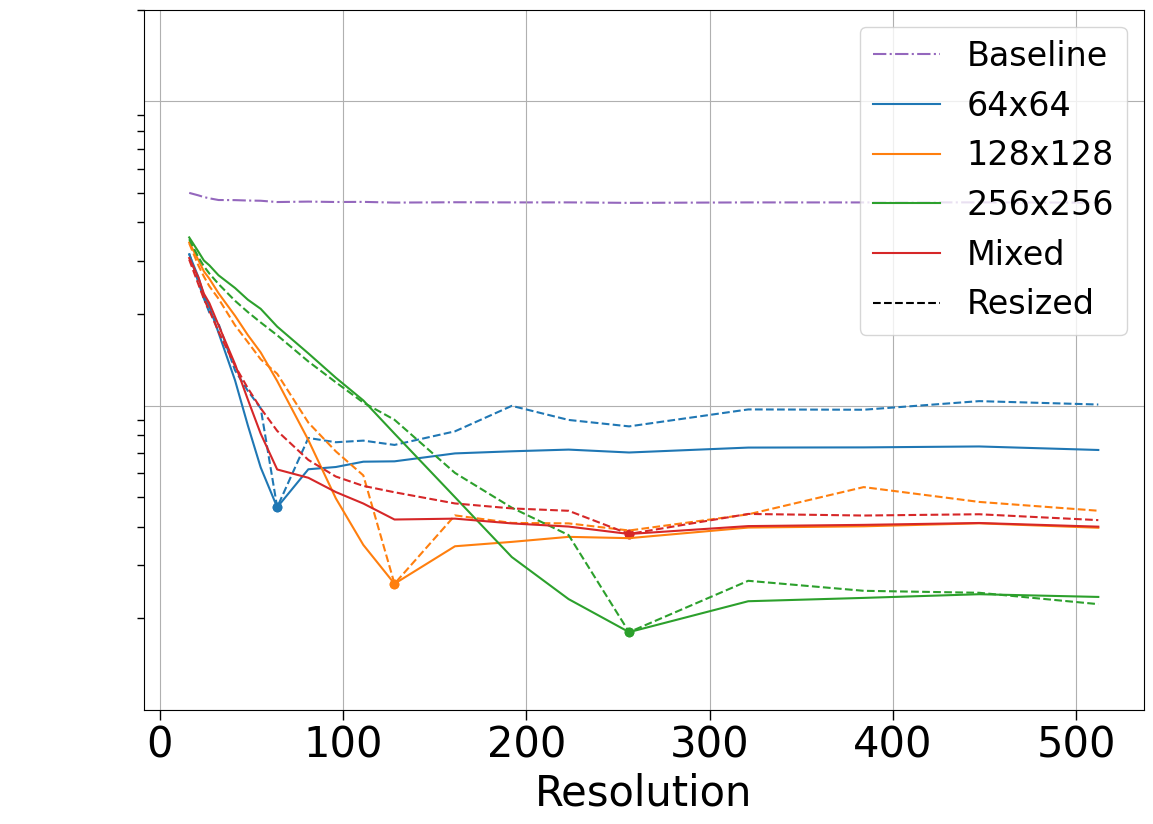

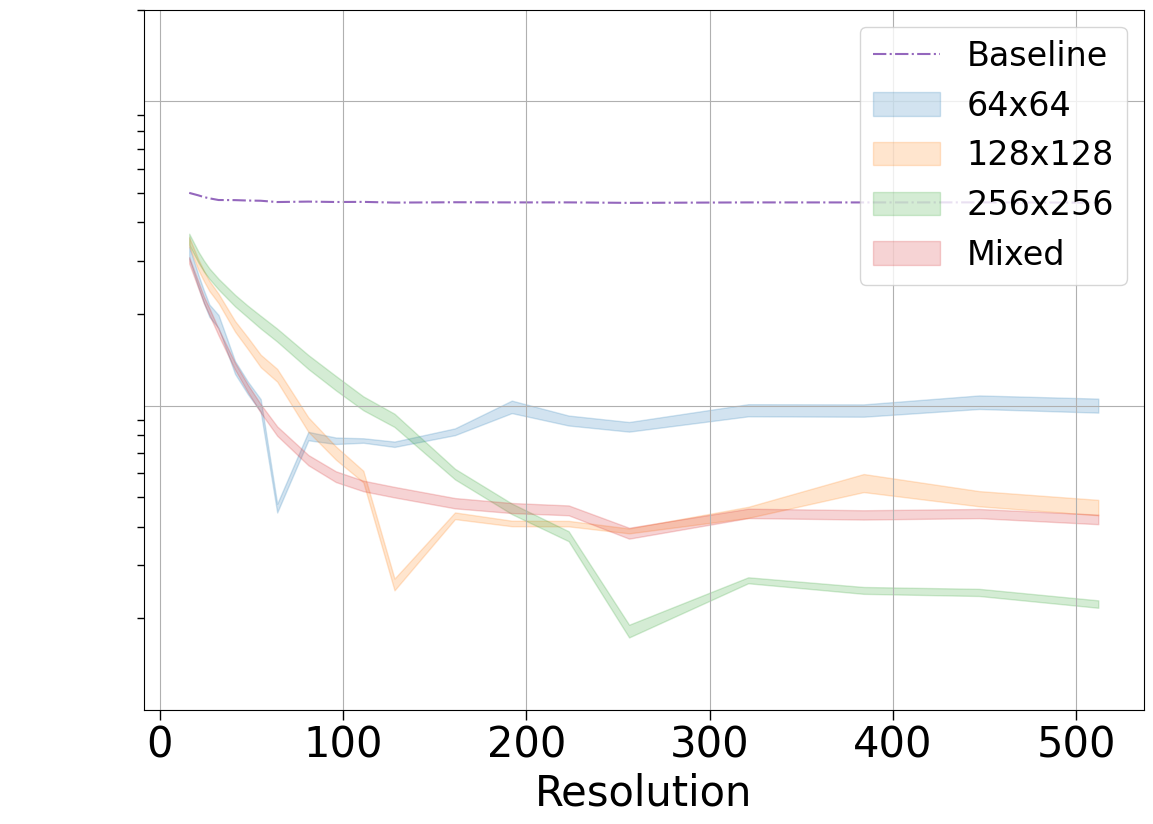

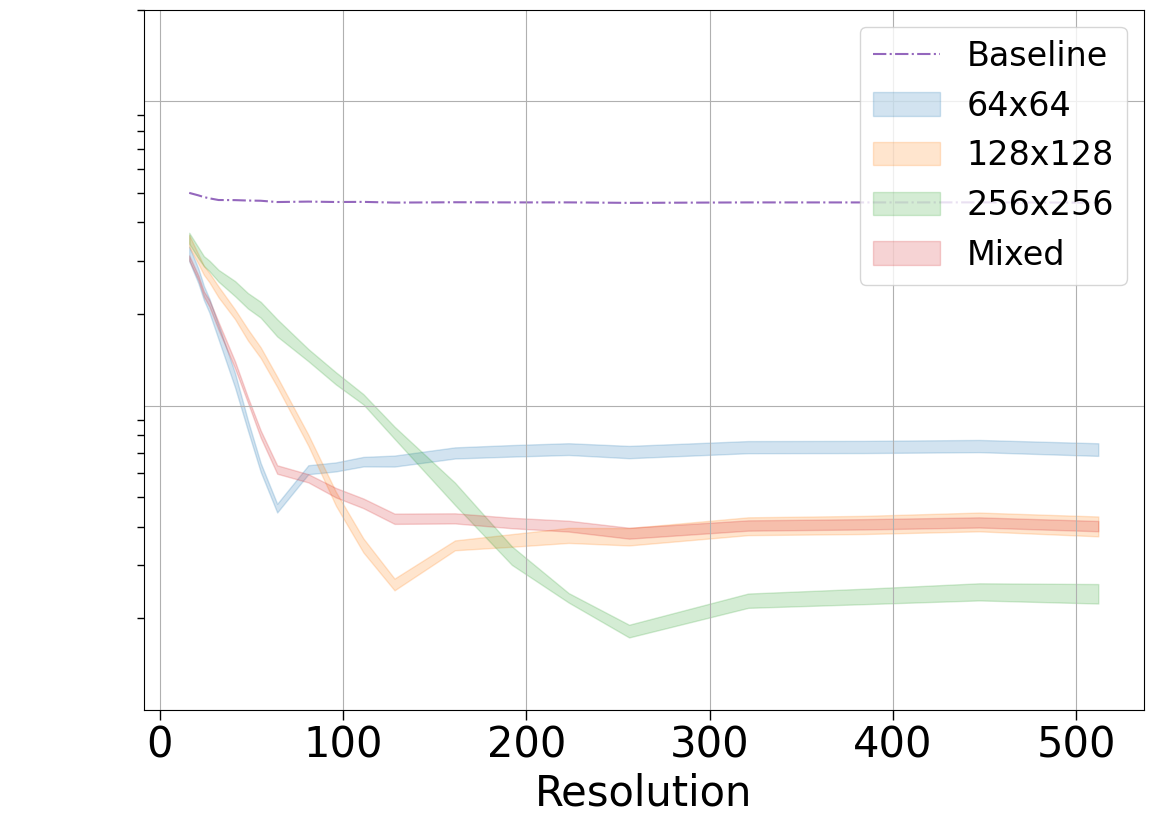

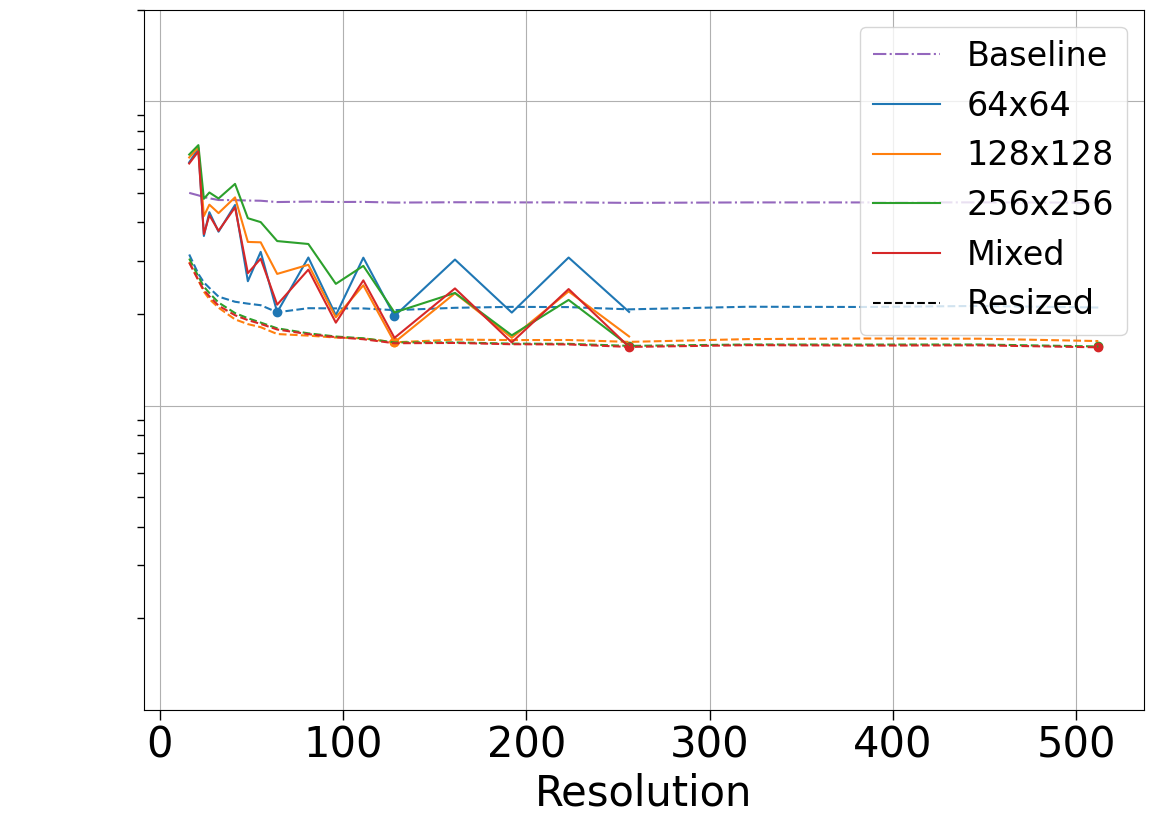

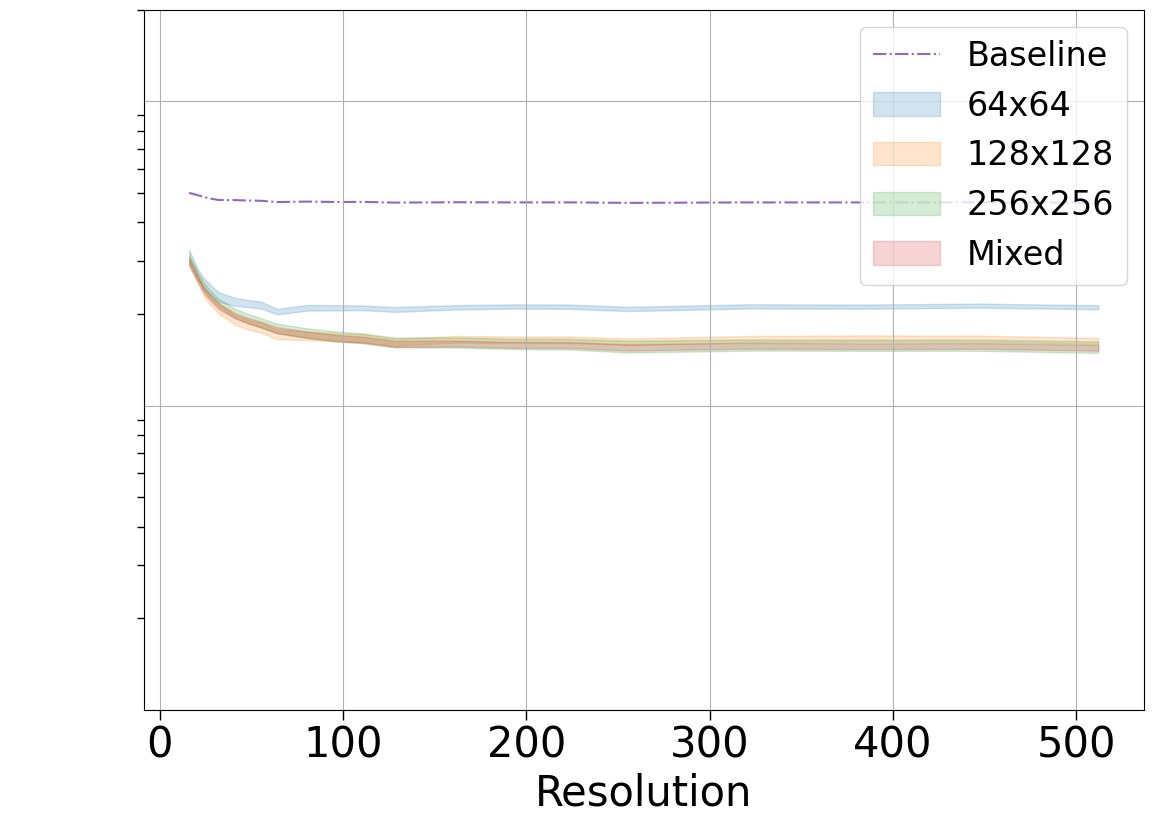

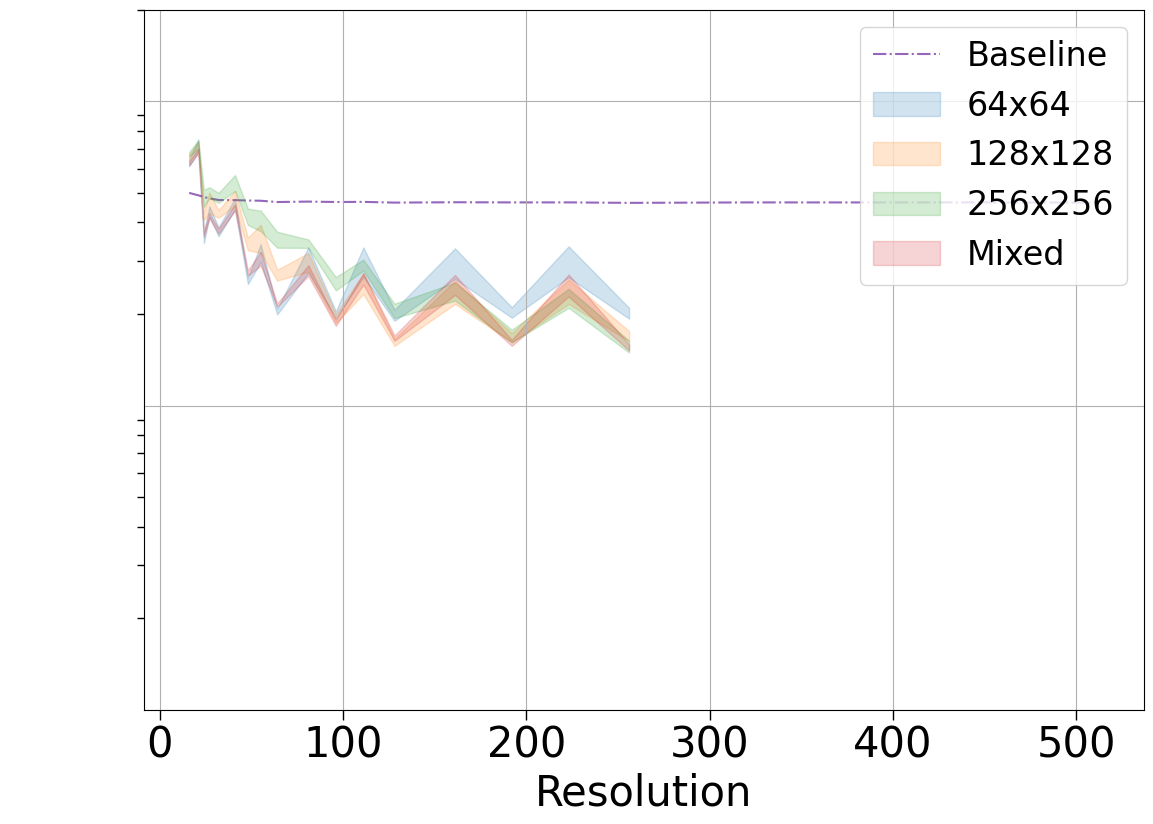

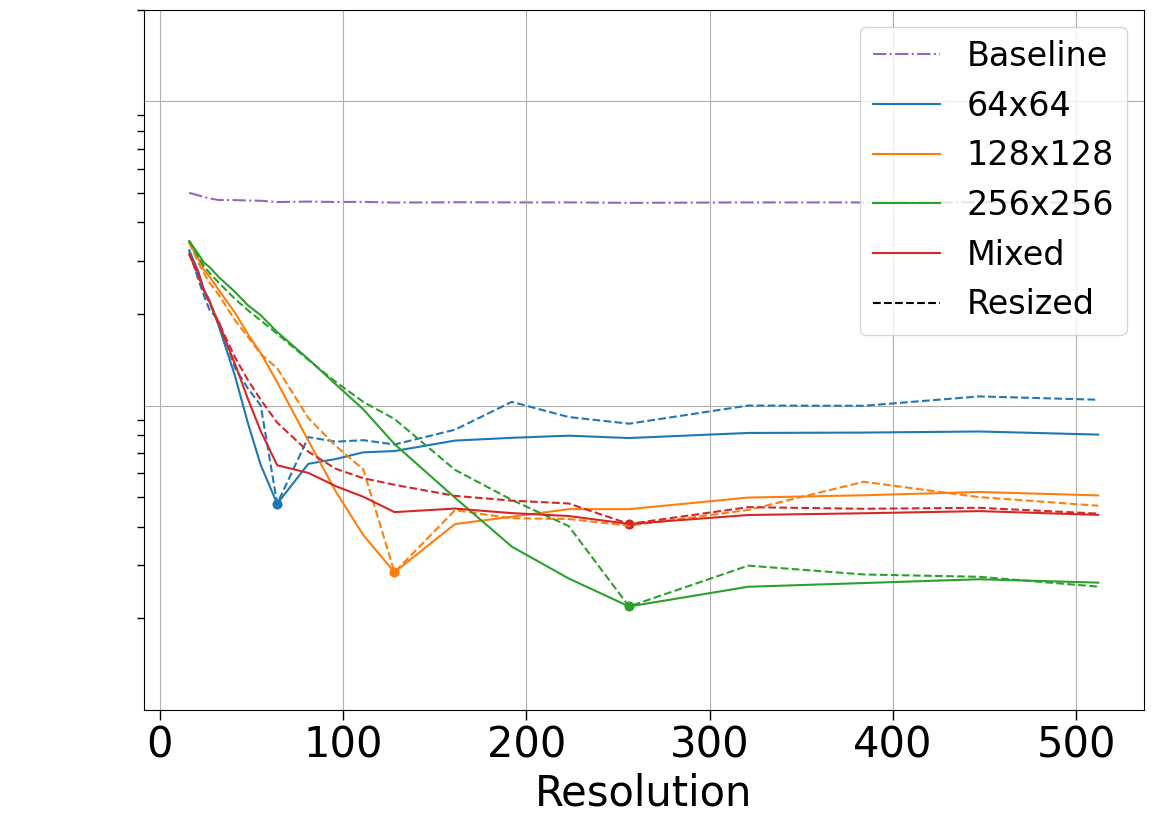

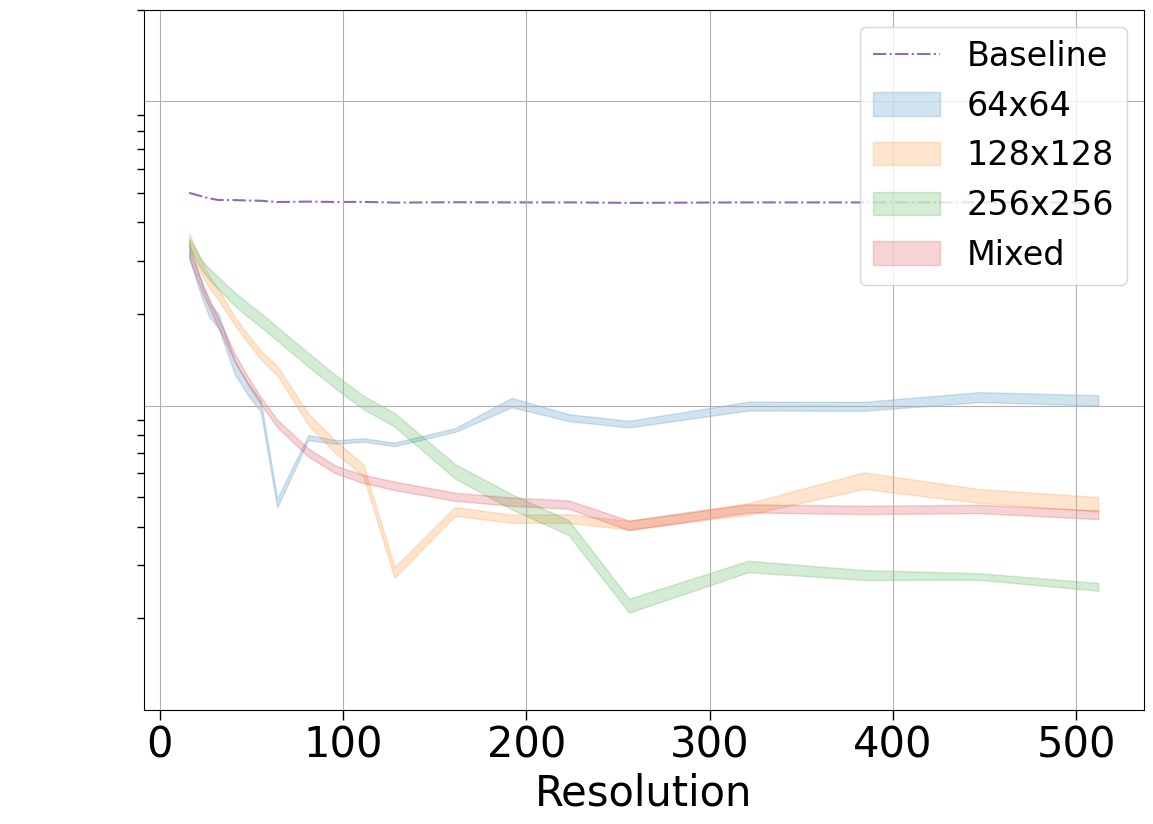

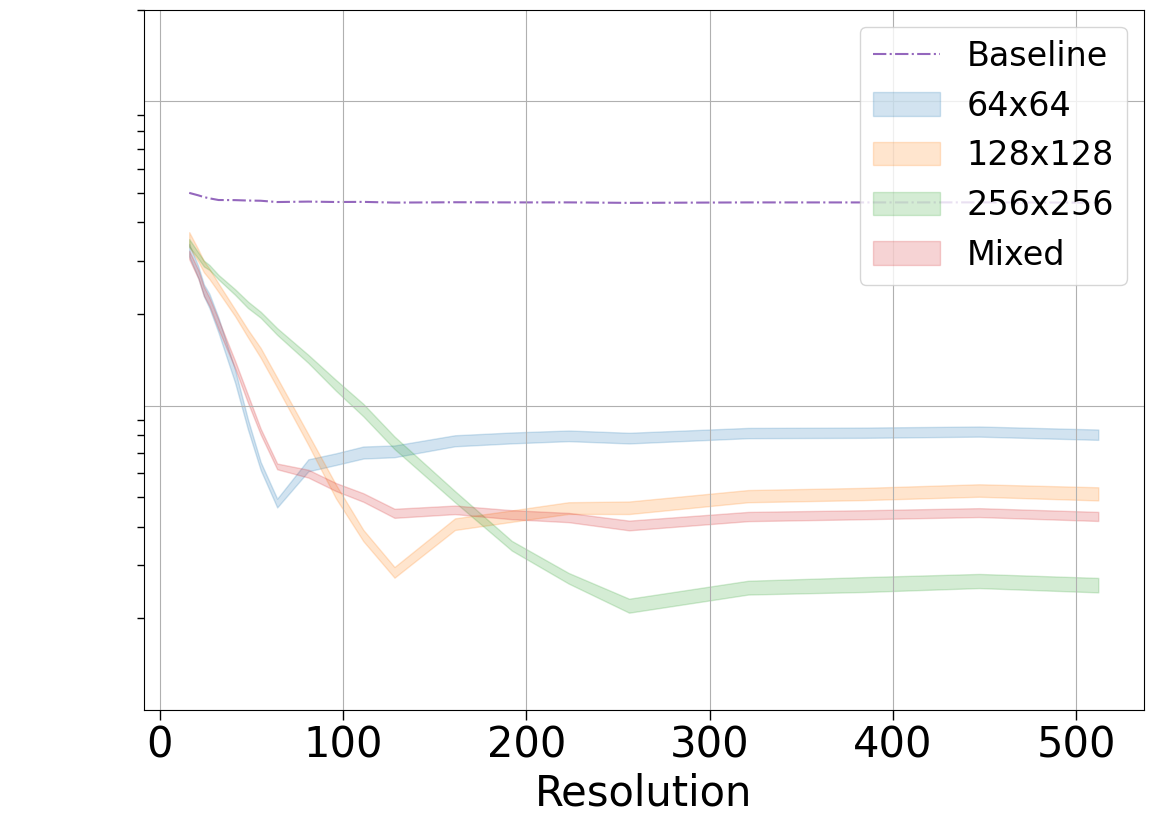

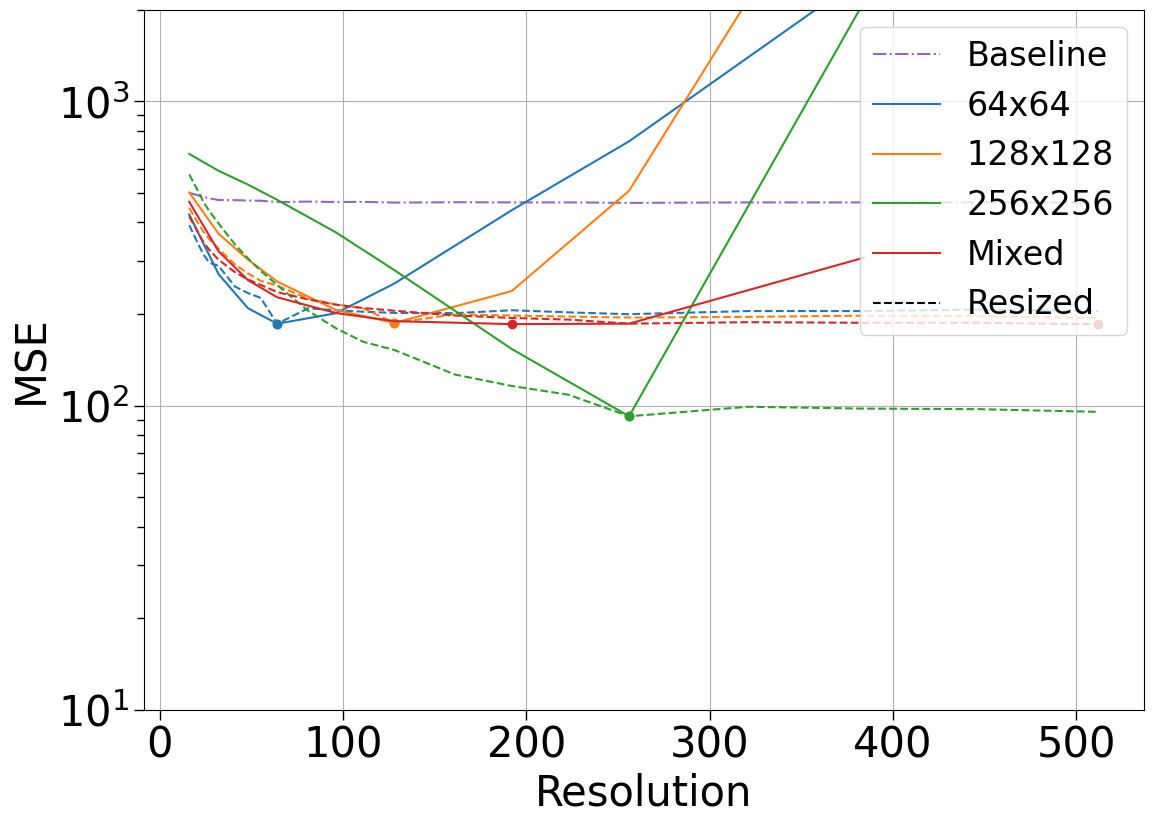

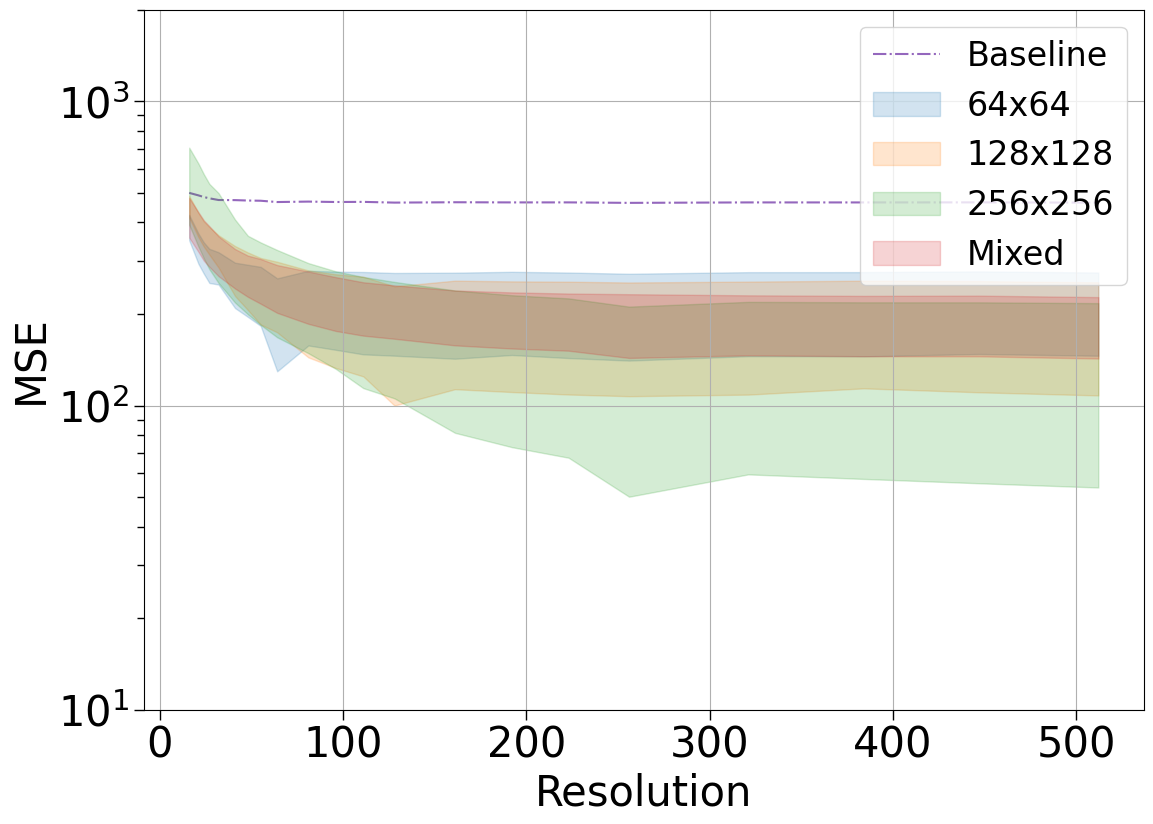

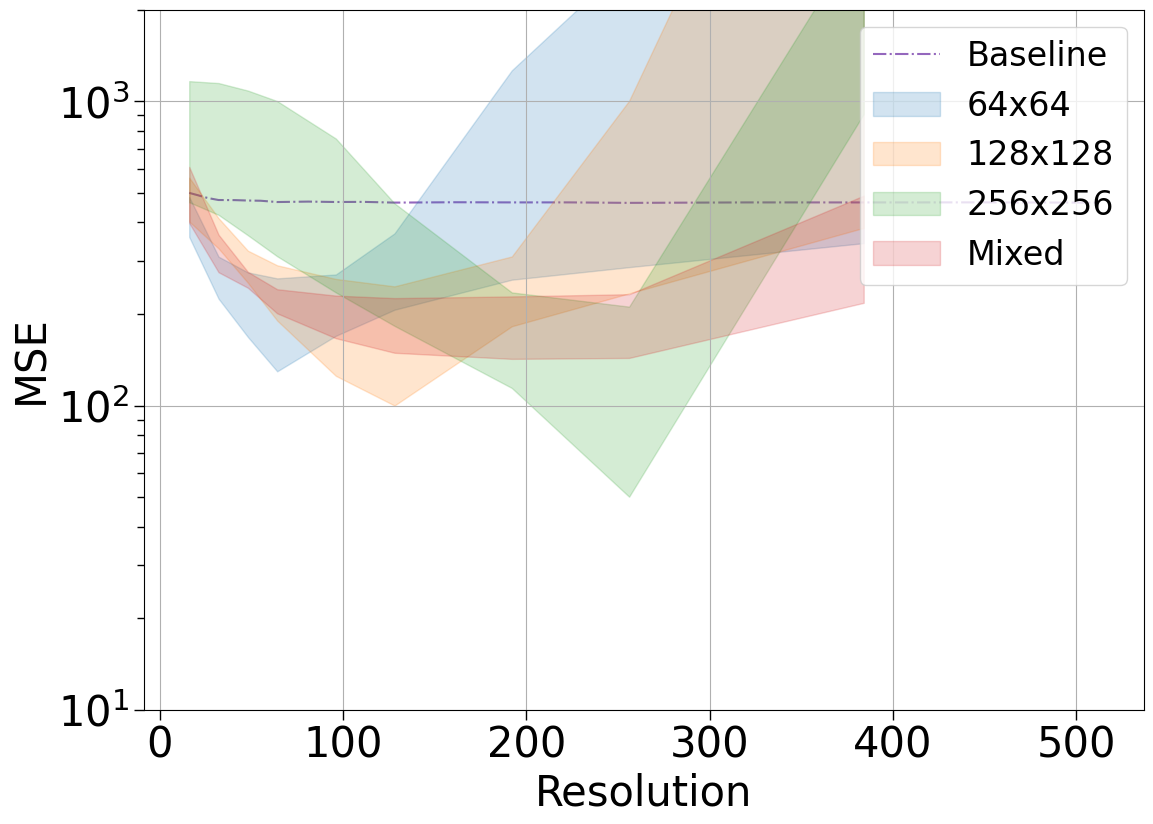

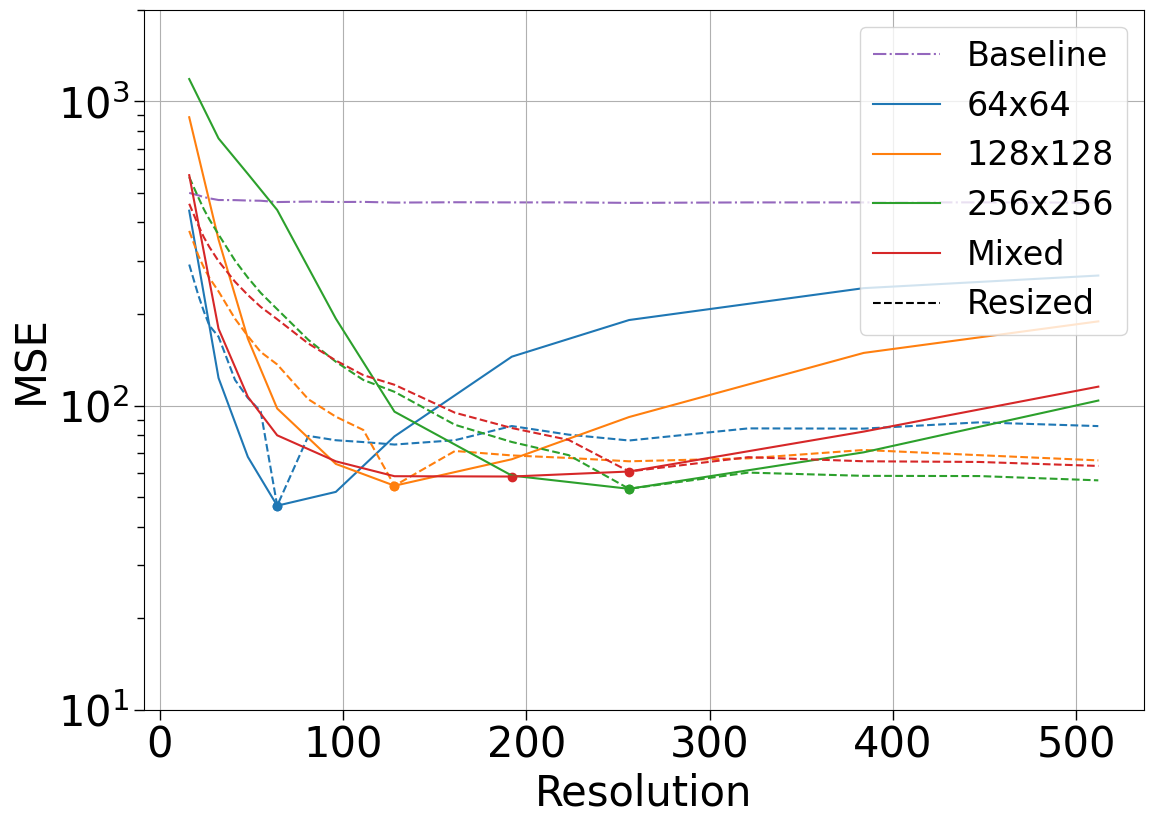

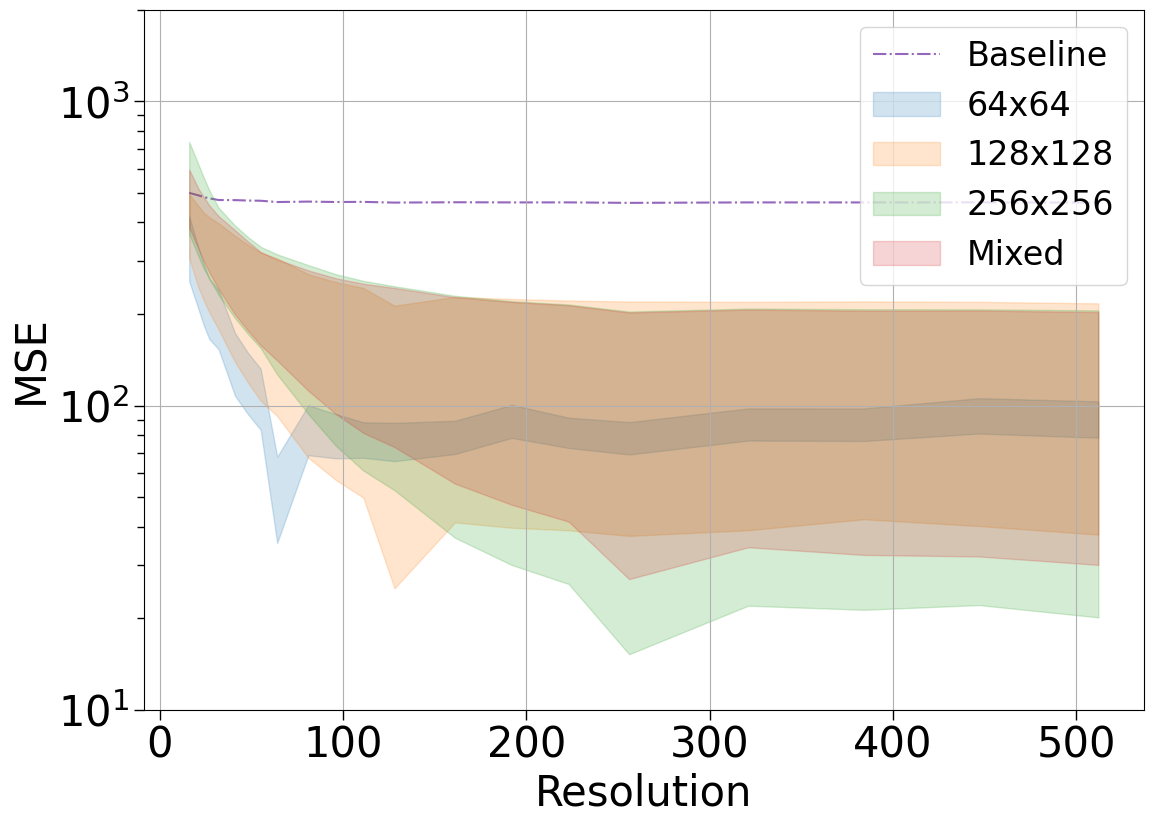

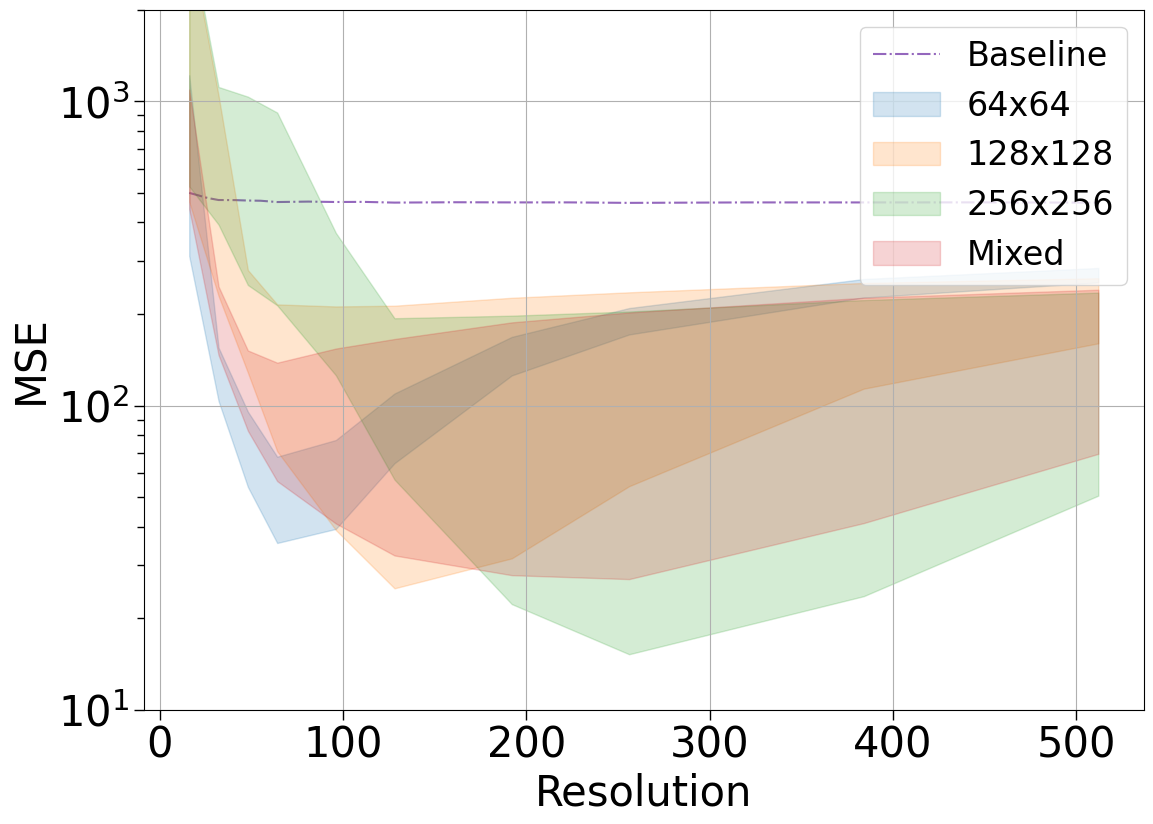

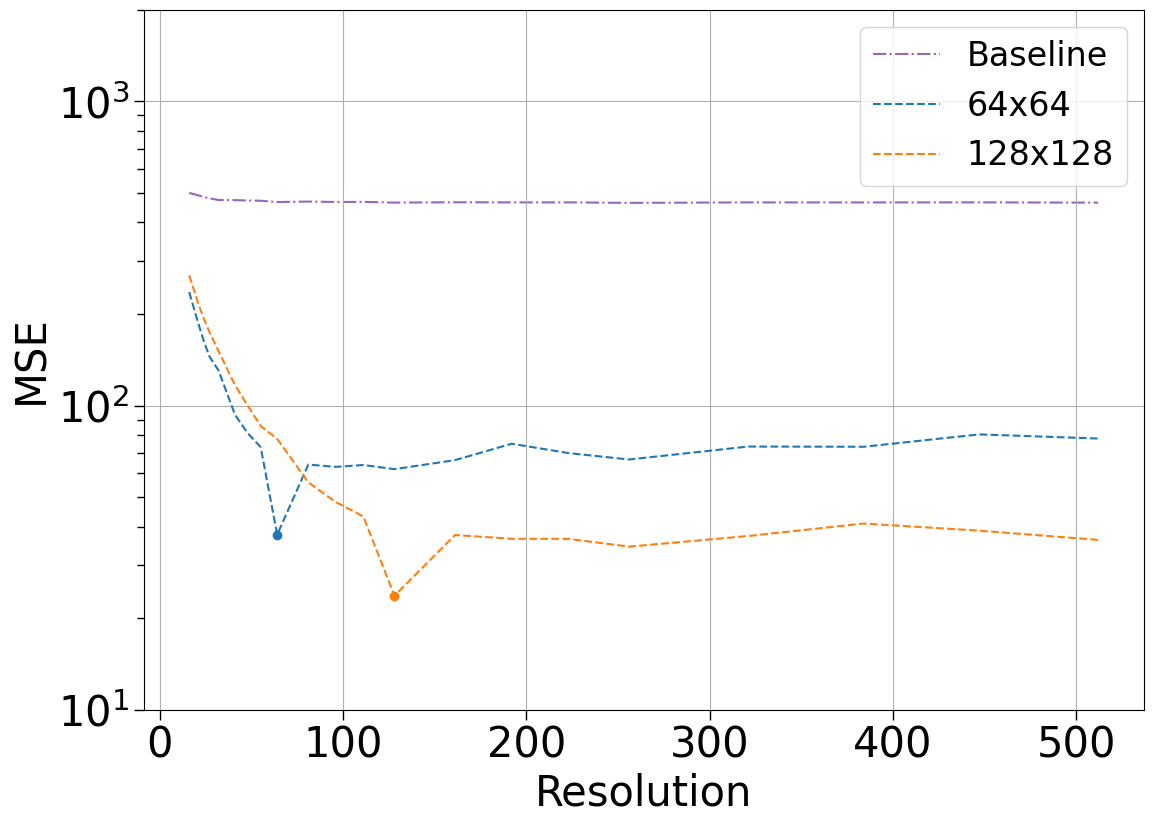

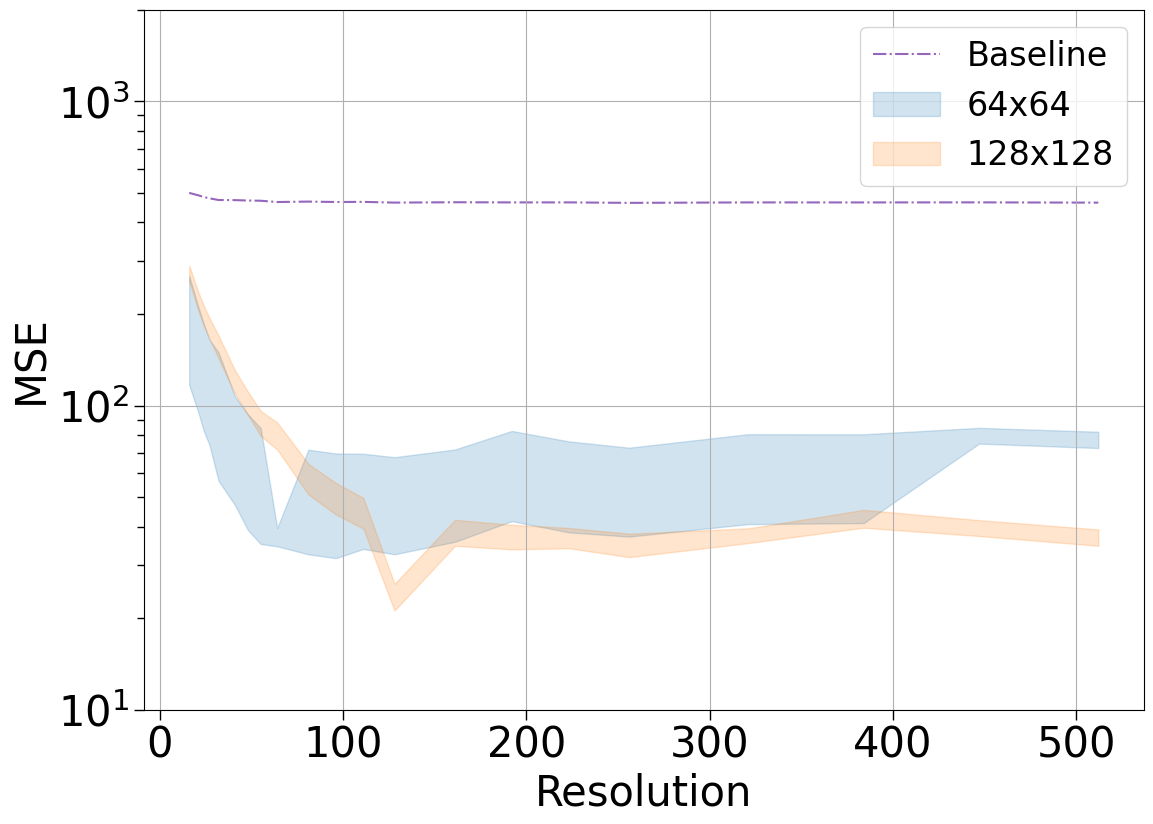

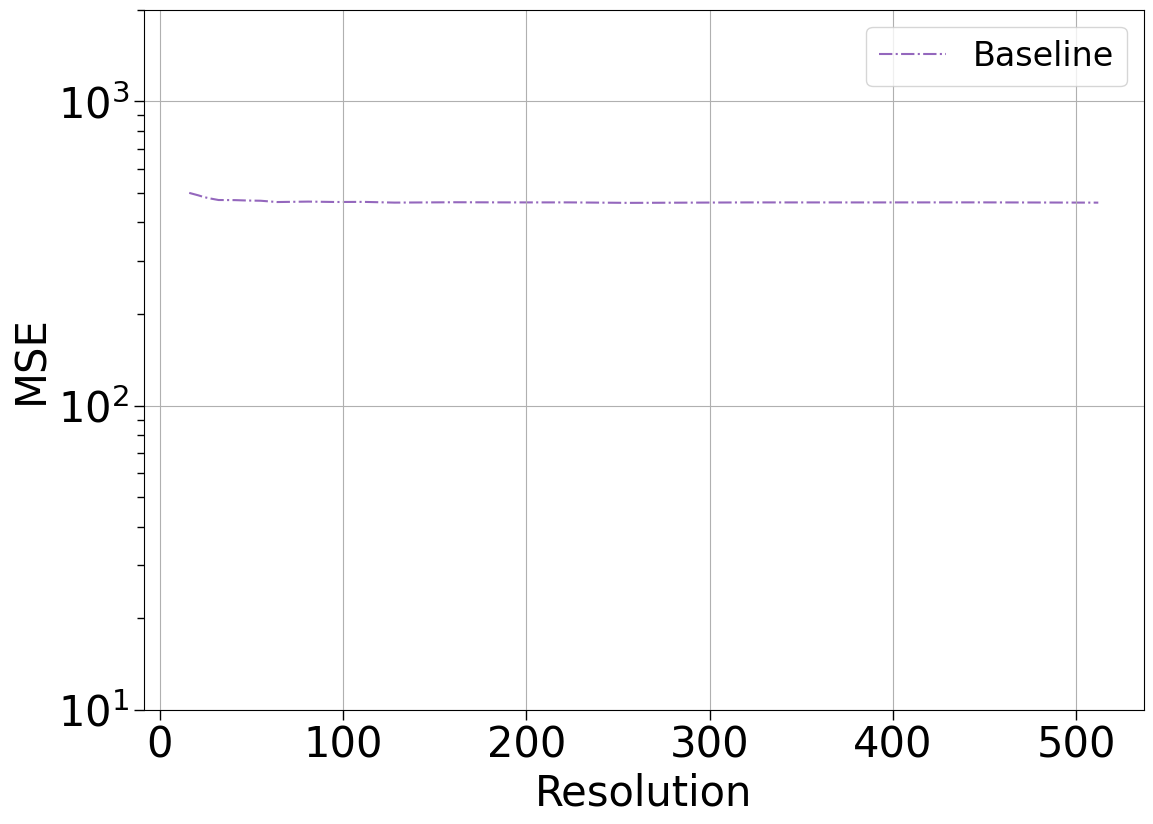

In [21]:
COLORS = {
    "64x64": "C0", 
    "128x128": "C1", 
    "256x256": "C2", 
    "mixed": "C3",
}
TITLES = {
    "UNet": "Classical U-Net",
    "Diff": "Differential U-Net",
    "CNO": "CNO",
    "FNO": "Spectral U-Net",
    "UFNO": "Spectral U-Net\n(resizing)",
    "UNO": "U-NO",
}

for model in {"UNet", "Diff", "CNO", "FNO", "UFNO", "UNO"}:
    raw_data = pd.read_csv(RUNS_DIR / f"Sweep-CNO-64x64-1" / "baseline.csv")
    raw_data = raw_data.loc[(raw_data["dataset"] != "all-avg") & (raw_data["metric"] == "loss")]
    baseline_labels = [int(x.split("x")[0]) for x in raw_data["dataset"]]
    baseline_losses = raw_data["value"].tolist()

    means_fig = plt.figure(figsize=(10, 7))
    means_axes = means_fig.add_axes((0.0, 0.0, 1.0, 1.0))
    means_axes.plot(baseline_labels, baseline_losses, "C4-.", label="Baseline", zorder=-999)
    resize_tubes_fig = plt.figure(figsize=(10, 7))
    resize_tubes_axes = resize_tubes_fig.add_axes((0.0, 0.0, 1.0, 1.0))
    resize_tubes_axes.plot(baseline_labels, baseline_losses, "C4-.", label="Baseline", zorder=-999)
    nonresize_tubes_fig = plt.figure(figsize=(10, 7))
    nonresize_tubes_axes = nonresize_tubes_fig.add_axes((0.0, 0.0, 1.0, 1.0))
    nonresize_tubes_axes.plot(baseline_labels, baseline_losses, "C4-.", label="Baseline", zorder=-999)

    for i, resolution in enumerate(["64x64", "128x128", "256x256", "mixed"]):
        if model.startswith("CNO") and resolution in ["256x256", "mixed"]:
            continue
        run = f"{model}-{resolution}-R"
        with warnings.catch_warnings():
            warnings.filterwarnings(action="ignore", message="Mean of empty slice")  # Supress useless "all-nan" nanmean warning 
            warnings.filterwarnings(action="ignore", message="Degrees of freedom <= 0 for slice")  # Supress useless "all-nan" nanstd warning
            warnings.filterwarnings(action="ignore", message="All-NaN slice encountered")  # Supress useless "all-nan" nanmin/nanmax warning
            mean = np.nanmean(data[data_runs == run], axis=1).squeeze()
            min_ = np.nanmin(data[data_runs == run], axis=1).squeeze()
            max_ = np.nanmax(data[data_runs == run], axis=1).squeeze()
            res = data_res[~np.isnan(mean)]
            min_ = min_[~np.isnan(mean)]
            max_ = max_[~np.isnan(mean)]
            mean = mean[~np.isnan(mean)]
            # for row in data[data_runs == run][0]:
            #     plt.plot(data_res[~np.isnan(row)], row[~np.isnan(row)], color=COLORS[run.split("-")[1]], alpha=0.2, zorder=-500)
            means_axes.plot(res, mean, "--", color=COLORS[run.split("-")[1]], label=run.split("-")[1].capitalize() if run.startswith("CNO") else None)
            means_axes.scatter(res[np.argmin(mean)], mean[np.argmin(mean)], color=COLORS[run.split("-")[1]])
            resize_tubes_axes.fill_between(res, min_, max_, color=COLORS[run.split("-")[1]], alpha=0.2, zorder=-500, label=run.split("-")[1].capitalize())
            # print(f"{run+':':25} {int(res[np.argmin(mean)]): >3d}x{int(res[np.argmin(mean)])}")
        if model.startswith("CNO"):
            continue
        run = f"{model}-{resolution}"
        with warnings.catch_warnings():
            warnings.filterwarnings(action="ignore", message="Mean of empty slice")  # Supress useless "all-nan" nanmean warning 
            warnings.filterwarnings(action="ignore", message="Degrees of freedom <= 0 for slice")  # Supress useless "all-nan" nanstd warning
            warnings.filterwarnings(action="ignore", message="All-NaN slice encountered")  # Supress useless "all-nan" nanmin/nanmax warning
            mean = np.nanmean(data[data_runs == run], axis=1).squeeze()
            min_ = np.nanmin(data[data_runs == run], axis=1).squeeze()
            max_ = np.nanmax(data[data_runs == run], axis=1).squeeze()
            res = data_res[~np.isnan(mean)]
            min_ = min_[~np.isnan(mean)]
            max_ = max_[~np.isnan(mean)]
            mean = mean[~np.isnan(mean)]
            # for row in data[data_runs == run][0]:
            #     plt.plot(data_res[~np.isnan(row)], row[~np.isnan(row)], color=COLORS[run.split("-")[1]], alpha=0.2, zorder=-500)
            means_axes.plot(res, mean, color=COLORS[run.split("-")[1]], label=run.split("-")[1].capitalize())
            means_axes.scatter(res[np.argmin(mean)], mean[np.argmin(mean)], color=COLORS[run.split("-")[1]])
            nonresize_tubes_axes.fill_between(res, min_, max_, color=COLORS[run.split("-")[1]], alpha=0.2, zorder=-500, label=run.split("-")[1].capitalize())
            # print(f"{run+':':25} {int(res[np.argmin(mean)]): >3d}x{int(res[np.argmin(mean)])}")
    #means_axes.set_title(f"{TITLES[model]}")
    if not model.startswith("CNO"):
        means_axes.plot([], [], "k--", label="Resized")
    means_axes.legend(loc="upper right")
    means_axes.set_xlabel("Resolution")
    means_axes.set_ylabel(METRIC.upper() if METRIC != "loss" else "MSE")
    means_axes.set_yscale("log")
    if METRIC == "loss":
        means_axes.set_ylim(1e1, 2e3)
    elif METRIC == "psnr":
        means_axes.set_ylim(20, 50)
    elif METRIC == "ssim":
        means_axes.set_ylim(1e-2, 1.0)
    means_axes.grid()
    if model in ["FNO", "UFNO", "UNO"]:
        means_axes.yaxis.label.set_color("white")
        means_axes.tick_params(axis="y", colors="white")
    means_fig.savefig(f"imgs/aa_{model.lower()}-{METRIC}.pdf", bbox_inches="tight")
    means_fig.show()
    #nonresize_tubes_axes.set_title(f"{model}")
    nonresize_tubes_axes.legend(loc="upper right")
    nonresize_tubes_axes.set_xlabel("Resolution")
    nonresize_tubes_axes.set_ylabel(METRIC.upper() if METRIC != "loss" else "MSE")
    nonresize_tubes_axes.set_yscale("log")
    if METRIC == "loss":
        nonresize_tubes_axes.set_ylim(1e1, 2e3)
    elif METRIC == "psnr":
        means_axes.set_ylim(20, 50)
    elif METRIC == "ssim":
        means_axes.set_ylim(1e-2, 1.0)
    nonresize_tubes_axes.grid()
    if model in ["FNO", "UFNO", "UNO"]:
        nonresize_tubes_axes.yaxis.label.set_color("white")
        nonresize_tubes_axes.tick_params(axis="y", colors="white")
    nonresize_tubes_fig.savefig(f"imgs/aa_{model.lower()}-{METRIC}-tubes-nonresize.pdf", bbox_inches="tight")
    nonresize_tubes_fig.show()
    #resize_tubes_axes.set_title(f"{model}")
    resize_tubes_axes.legend(loc="upper right")
    resize_tubes_axes.set_xlabel("Resolution")
    resize_tubes_axes.set_ylabel(METRIC.upper() if METRIC != "loss" else "MSE")
    resize_tubes_axes.set_yscale("log")
    if METRIC == "loss":
        resize_tubes_axes.set_ylim(1e1, 2e3)
    elif METRIC == "psnr":
        means_axes.set_ylim(20, 50)
    elif METRIC == "ssim":
        means_axes.set_ylim(1e-2, 1.0)
    resize_tubes_axes.grid()
    if model in ["FNO", "UFNO", "UNO"]:
        resize_tubes_axes.yaxis.label.set_color("white")
        resize_tubes_axes.tick_params(axis="y", colors="white")
    resize_tubes_fig.savefig(f"imgs/aa_{model.lower()}-{METRIC}-tubes-resize.pdf", bbox_inches="tight")
    resize_tubes_fig.show()
pass